# EnergyPlus → BRCM → RC operator notebook

This notebook operates the implemented Python workflow without modifying the original MATLAB toolbox:

`EnergyPlus IDF → normalized objects → seven BRCM tables → ThermalModelData → ThermalModel → optional BuildingModel → simulation`

> **Compatibility note:** Building north rotation is ignored to preserve the observable MATLAB BRCM behavior. Relative coordinates still apply zone origin and zone north rotation.

> Stage 8 validates structural and physical consistency. It does **not** establish predictive equivalence with EnergyPlus or exact numerical parity with MATLAB.

For an artifact-compatible Python counterpart to `matlab_validation/run_brcm_end_to_end.m`, use `BRCM_Python_MATLAB_Comparable_Validation.ipynb`. Both workflows use the same representative IDF and deterministic simulation settings.

## 1. Environment and input

Run this notebook from anywhere inside the repository. Change `IDF_PATH` to your supported EnergyPlus IDF. Bundled native IDDs cover EnergyPlus 7.0, 7.1, 7.2, 8.0, and 8.1; later 8.x files use the 8.1 IDD with a warning, matching MATLAB's fallback.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd

def find_repository(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'brcm').is_dir():
            return candidate
    raise RuntimeError('Could not find repository root containing src/brcm')

REPO = find_repository(Path.cwd().resolve())
SRC = REPO / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import brcm
from brcm.energyplus import (
    audit_conversion, conversion_to_thermal_model_data,
    convert_idf_to_brcm, convert_idf_to_brcm_data,
)

IDF_PATH = REPO / 'tests' / 'fixtures' / 'energyplus' / 'representative_multizone.idf'
assert IDF_PATH.is_file(), IDF_PATH
print('Repository:', REPO)
print('IDF:', IDF_PATH)

Repository: /Users/rui.bo/Desktop/BASE/_toolkit/BRCMToolbox_v1.03
IDF: /Users/rui.bo/Desktop/BASE/_toolkit/BRCMToolbox_v1.03/tests/fixtures/energyplus/representative_multizone.idf


## 2. Convert in memory

The in-memory route avoids temporary CSV files. `ConversionResult` contains normalized EnergyPlus records, all seven BRCM tables, ignored object types, and captured warnings.

In [2]:
conversion = convert_idf_to_brcm_data(IDF_PATH)
data = conversion_to_thermal_model_data(conversion)
thermal_model = brcm.generate_thermal_model(data)
audit = audit_conversion(conversion, thermal_model)

pd.Series(audit.__dict__, name='value').to_frame()

,value
energyplus_version,8.1
zones,2
surfaces,6
windows,1
building_elements,6
rc_states,8
ambient_boundaries,2
ground_boundaries,1
adiabatic_boundaries,1
interzone_boundaries,2


In [3]:
if audit.warnings:
    print('Conversion warnings:')
    for warning in audit.warnings:
        print(' •', warning)
else:
    print('No conversion warnings.')
print('Ignored object types:', audit.ignored_object_types or 'none')

Conversion warnings:
 • Ignoring MATLAB-unsupported EnergyPlus objects: ['WindowMaterial:SimpleGlazingSystem']
Ignored object types: ('WindowMaterial:SimpleGlazingSystem',)


## 3. Pipeline monitor

Run the next cell whenever the IDF changes. It times each stage and reports whether conversion, table validation, RC generation, numerical health, MATLAB availability, and MATLAB reference fixtures are ready. A missing MATLAB runtime or fixture is reported as `WAITING`, not as a Python failure.

In [ ]:
import shutil
import time

monitor_rows = []
def monitored(stage, operation):
    started = time.perf_counter()
    try:
        value = operation()
        monitor_rows.append((stage, 'PASS', time.perf_counter() - started, ''))
        return value
    except Exception as error:
        monitor_rows.append((stage, 'FAIL', time.perf_counter() - started, str(error)))
        raise

monitored_conversion = monitored('IDF parsing and conversion', lambda: convert_idf_to_brcm_data(IDF_PATH))
monitored_data = monitored('Seven-table validation', lambda: conversion_to_thermal_model_data(monitored_conversion))
monitored_model = monitored('Thermal RC generation', lambda: brcm.generate_thermal_model(monitored_data))
monitored('Finite matrices', lambda: (_ for _ in ()).throw(ValueError('non-finite matrix')) if not all(np.isfinite(x).all() for x in (monitored_model.A, monitored_model.Bq, monitored_model.Xcap)) else True)
monitored('Positive capacitances', lambda: (_ for _ in ()).throw(ValueError('non-positive capacitance')) if not np.all(np.diag(monitored_model.Xcap) > 0) else True)

matlab_command = shutil.which('matlab')
matlab_fixture = REPO / 'tests' / 'fixtures' / 'matlab' / 'manifest.json'
monitor_rows.append(('MATLAB runtime', 'READY' if matlab_command else 'WAITING', 0.0, matlab_command or 'MATLAB is not installed/discoverable'))
monitor_rows.append(('MATLAB parity fixture', 'READY' if matlab_fixture.exists() else 'WAITING', 0.0, str(matlab_fixture)))

pipeline_monitor = pd.DataFrame(monitor_rows, columns=['stage', 'status', 'seconds', 'detail']).set_index('stage')
display(pipeline_monitor)
print('Python pipeline:', 'PASS' if not (pipeline_monitor.status == 'FAIL').any() else 'FAIL')

## 4. Inspect the seven BRCM tables

Identifiers and row order are part of the model contract. Do not reorder these tables before generating the model. Empty tables still retain their header row.

In [4]:
table_frames = {
    name: pd.DataFrame(rows[1:], columns=rows[0])
    for name, rows in conversion.tables.items()
}
pd.DataFrame({
    'table': list(table_frames),
    'rows': [len(frame) for frame in table_frames.values()],
}).set_index('table')

,rows
table,
zones,2
buildingelements,6
constructions,5
materials,4
windows,1
parameters,9
nomassconstructions,0


In [5]:
# Change the key to inspect another table.
table_frames['buildingelements']

,identifier,description,construction_identifier,adjacent_A,adjacent_B,window_identifier,area,vertices
0,B0001,EP Surface Names:West Outside,C0001,AMB,Z0001,W0001,12,"(0,0,0),(0,4,0),(0,4,3),(0,0,3)"
1,B0002,"EP Surface Names:West Partition,East Partition",C0004,Z0002,Z0001,,12,"(4,0,0),(4,4,0),(4,4,3),(4,0,3)"
2,B0003,EP Surface Names:East Outside,C0001,AMB,Z0002,,12,"(8,4,0),(8,0,0),(8,0,3),(8,4,3)"
3,B0004,EP Surface Names:West Ground,C0002,GND,Z0001,,16,"(0,0,0),(0,4,0),(4,4,0),(4,0,0)"
4,B0005,EP Surface Names:East Adiabatic,C0003,ADB,Z0002,,16,"(4,0,3),(8,0,3),(8,4,3),(4,4,3)"
5,B0006,West Furniture,C0005,Z0001,Z0001,,3,


## 5. Inspect and validate the thermal RC model

The continuous model is `dx/dt = A x + Bq q`. Time inside these matrices is in seconds: `A` has units s⁻¹, capacitances are J/K, and heat-flux inputs are W. Matrix axes follow the displayed identifier order.

In [6]:
matrix_summary = pd.DataFrame([
    ('A', thermal_model.A.shape, np.count_nonzero(thermal_model.A), np.isfinite(thermal_model.A).all()),
    ('Bq', thermal_model.Bq.shape, np.count_nonzero(thermal_model.Bq), np.isfinite(thermal_model.Bq).all()),
    ('Xcap', thermal_model.Xcap.shape, np.count_nonzero(thermal_model.Xcap), np.isfinite(thermal_model.Xcap).all()),
], columns=['matrix', 'shape', 'nonzeros', 'finite']).set_index('matrix')
assert np.all(np.diag(thermal_model.Xcap) > 0)
display(matrix_summary)
display(pd.DataFrame({
    'state': thermal_model.state_identifiers,
    'heat_flux': thermal_model.heat_flux_identifiers,
    'capacity_J_per_K': np.diag(thermal_model.Xcap),
}))

,shape,nonzeros,finite
matrix,,,
A,"(8, 8)",22,True
Bq,"(8, 8)",8,True
Xcap,"(8, 8)",8,True


,state,heat_flux,capacity_J_per_K
0,x_Z0001,q_Z0001,4.386777e+04
1,x_Z0002,q_Z0002,4.386777e+04
2,x_B0001_L1_s1_AMBZ0001,q_B0001_L1_s1_AMBZ0001,1.512000e+06
3,x_B0002_L1_s1_Z0002Z0001,q_B0002_L1_s1_Z0002Z0001,4.752000e+06
4,x_B0003_L1_s1_AMBZ0002,q_B0003_L1_s1_AMBZ0002,1.814400e+06
5,x_B0004_L1_s1_GNDZ0001,q_B0004_L1_s1_GNDZ0001,6.336000e+06
6,x_B0005_L1_s1_ADBZ0002,q_B0005_L1_s1_ADBZ0002,6.336000e+06
7,x_B0006_L1_s1_Z0001Z0001,q_B0006_L1_s1_Z0001Z0001,1.188000e+06


In [7]:
boundary_summary = {name: len(items) for name, items in thermal_model.boundary_conditions.items()}
boundary_summary

{'ambient': 2, 'adiabatic': 1, 'ground': 1, 'user_defined': 0}

## 6. Optional BuildingModel composition and discretization

An IDF supplies the thermal model but does not declare BRCM EHF control models. The example therefore composes an empty-EHF `BuildingModel`. Existing `InternalGains`, `Radiators`, `BEHeatfluxes`, `BuildingHull`, or `AHU` instances can be supplied in the list when their configuration data are available. Sampling time is in hours.

In [8]:
EHF_MODELS = []  # e.g. [internal_gains, radiators, ...]
building_model = brcm.BuildingModel(thermal_model, EHF_MODELS)
building_model.discretize(0.25)
{
    'x': len(building_model.identifiers.x),
    'u': len(building_model.identifiers.u),
    'v': len(building_model.identifiers.v),
    'Ad': building_model.Ad.shape,
    'Bdu': building_model.Bdu.shape,
    'Bdv': building_model.Bdv.shape,
}

{'x': 8, 'u': 0, 'v': 0, 'Ad': (8, 8), 'Bdu': (8, 0), 'Bdv': (8, 0)}

## 7. Deterministic thermal simulation

Boundary temperatures are not automatically injected into `q`. The callback below applies a constant ambient temperature through every ambient boundary as `q = G(Tamb − x_boundary)`. It also adds optional zone heating directly to the selected zone heat-flux input.

In [9]:
INITIAL_TEMPERATURE_C = 20.0
AMBIENT_TEMPERATURE_C = 30.0
ZONE_HEATING_W = 0.0
SAMPLE_TIME_HOURS = 1 / 60
N_STEPS = 60

state_index = {name: i for i, name in enumerate(thermal_model.state_identifiers)}
q_index = {name: i for i, name in enumerate(thermal_model.heat_flux_identifiers)}
ambient_boundaries = thermal_model.boundary_conditions['ambient']
zone_state = next(name for name in thermal_model.state_identifiers if name.startswith('x_Z'))

def inputs(current_x, time_hours, identifiers):
    q = np.zeros((len(identifiers.q), 1))
    for boundary in ambient_boundaries:
        boundary_state = boundary.identifier_1 if boundary.identifier_1 in state_index else boundary.identifier_2
        corresponding_q = 'q' + boundary_state[1:]
        q[q_index[corresponding_q], 0] += boundary.value * (AMBIENT_TEMPERATURE_C - current_x[state_index[boundary_state], 0])
    q[q_index['q' + zone_state[1:]], 0] += ZONE_HEATING_W
    return q

x0 = np.full(len(thermal_model.state_identifiers), INITIAL_TEMPERATURE_C)
simulation = brcm.simulate_tm(thermal_model, SAMPLE_TIME_HOURS, x0, N_STEPS, inputs)
assert np.isfinite(simulation.X_full).all()
print('X_full shape:', simulation.X_full.shape)
print('Temperature range:', simulation.X_full.min(), simulation.X_full.max())

X_full shape: (8, 61)
Temperature range: 20.0 21.235470400144496


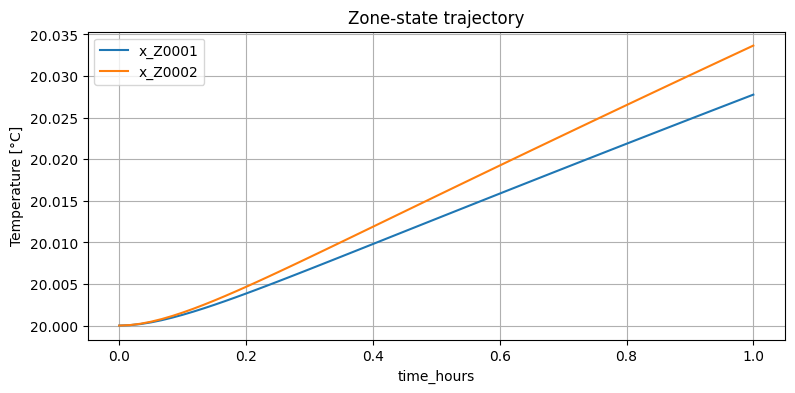

In [10]:
time_full = np.arange(N_STEPS + 1) * SAMPLE_TIME_HOURS
zone_indices = [i for i, name in enumerate(thermal_model.state_identifiers) if name.startswith('x_Z')]
trajectory = pd.DataFrame(
    simulation.X_full[zone_indices].T,
    index=pd.Index(time_full, name='time_hours'),
    columns=[thermal_model.state_identifiers[i] for i in zone_indices],
)
trajectory.plot(figsize=(9, 4), grid=True, ylabel='Temperature [°C]', title='Zone-state trajectory');

## 8. Runtime health dashboard

This compact dashboard can be refreshed after changing simulation inputs. It monitors trajectory dimensions, finite values, temperature range, and deterministic repeatability.

In [ ]:
repeat = brcm.simulate_tm(thermal_model, SAMPLE_TIME_HOURS, x0, N_STEPS, inputs)
health = {
    'pipeline_status': 'PASS' if not (pipeline_monitor.status == 'FAIL').any() else 'FAIL',
    'state_shape': simulation.X_full.shape,
    'expected_shape': (len(thermal_model.state_identifiers), N_STEPS + 1),
    'all_finite': bool(np.isfinite(simulation.X_full).all()),
    'minimum_temperature_C': float(simulation.X_full.min()),
    'maximum_temperature_C': float(simulation.X_full.max()),
    'deterministic_repeat': bool(np.array_equal(simulation.X_full, repeat.X_full)),
    'conversion_warning_count': len(audit.warnings),
    'matlab_runtime': 'READY' if matlab_command else 'WAITING',
    'matlab_fixture': 'READY' if matlab_fixture.exists() else 'WAITING',
}
pd.Series(health, name='value').to_frame()

## 9. Optional portable table export

This writes the seven semicolon-delimited tables accepted by `ThermalModelData.from_directory`. Choose a new or empty directory unless `overwrite=True` is intentional.

In [11]:
EXPORT_TABLES = False
OUTPUT_DIRECTORY = REPO / 'notebooks' / 'outputs' / IDF_PATH.stem / 'ThermalModel'
if EXPORT_TABLES:
    convert_idf_to_brcm(IDF_PATH, OUTPUT_DIRECTORY, overwrite=True)
    reloaded = brcm.ThermalModelData.from_directory(OUTPUT_DIRECTORY)
    print('Exported and reloaded:', OUTPUT_DIRECTORY)

## Operational notes and current limits

- Original MATLAB sources remain unchanged.
- Building north rotation is ignored for MATLAB compatibility. Zone north rotation and zone-origin translation are applied for relative coordinates.
- Identifier and table ordering are observable model behavior; do not sort them manually.
- Window physics use the MATLAB-compatible simplified U/G parameter representation.
- Unsupported thermal EnergyPlus objects raise clear errors. MATLAB-ignored glazing, shading, and material-property objects are listed in the conversion audit.
- Later EnergyPlus 8.x files are parsed using the bundled 8.1 IDD with a warning. Modern EnergyPlus feature coverage is not implied.
- Ground and ambient temperatures must be supplied as heat-flux trajectories or callback logic during thermal-only simulation.
- Stage 8 checks structural and physical coherence only. MATLAB numerical parity awaits exported MATLAB fixtures, and EnergyPlus-vs-BRCM dynamic equivalence requires a separate comparison/calibration stage.